In [1]:
import pandas as pd
import numpy as np

In [2]:
# Updated data labeling
df = pd.read_csv('DevEvObject_2025-01-23.csv')

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3275 entries, 0 to 3274
Columns: 134 entries, ID_subjsess to object3_action_state_clean_point_flipped
dtypes: float64(28), int64(5), object(101)
memory usage: 3.3+ MB
None


In [4]:
print(df.columns.tolist())

['ID_subjsess', 'ID_subj', 'ID_sess', 'ID_sex', 'ID_agegroup', 'ID_bdate', 'ID_tdate', 'ID_race', 'ID_ethnicity', 'ID_weight1', 'ID_weight2', 'ID_height1', 'ID_height2', 'ID_rightleg1', 'ID_rightleg2', 'ID_leftleg1', 'ID_leftleg2', 'ID_locomotor', 'onset', 'offset', 'task_ordinal', 'task_task', 'computervision_ordinal', 'computervision_videopreset', 'usedata_ordinal', 'usedata_playdata', 'object1_clean_ordinal', 'object1_clean_obj', 'object1_action_state_clean_dur_actstateord', 'object1_action_state_clean_dur_hands', 'object1_action_state_clean_dur_mouth', 'object1_action_state_clean_dur_feet', 'object1_action_state_clean_dur_wholebody', 'object1_action_state_clean_dur_object', 'object1_action_state_clean_dur_action', 'object1_action_state_clean_dur_noise', 'object1_action_state_clean_dur_detach', 'object1_action_state_clean_dur_reattach', 'object1_action_state_clean_dur_takeout', 'object1_action_state_clean_dur_putin', 'object1_action_state_clean_dur_popup', 'object1_action_state_clea

In [5]:
# convert all nan to one type
df = df.fillna(np.nan)


In [6]:
# Check for rows where an object has both point and dur actions
overlapping_actions = []

for obj_num in range(1,4):
    point_col = f'object{obj_num}_action_state_clean_point_action'
    dur_col = f'object{obj_num}_action_state_clean_dur_action'
    obj_col = f'object{obj_num}_clean_obj'
    
    # Find rows where both point and dur actions exist
    mask = (~df[point_col].isna()) & (~df[dur_col].isna())
    overlapping = df[mask]
    
    if not overlapping.empty:
        for _, row in overlapping.iterrows():
            overlapping_actions.append({
                'object': row[obj_col],
                'point_action': row[point_col],
                'dur_action': row[dur_col],
                'row_index': row.name
            })

if overlapping_actions:
    print("Found rows with both point and dur actions:")
    for item in overlapping_actions:
        print(f"Row {item['row_index']}: Object {item['object']} has point action '{item['point_action']}' and dur action '{item['dur_action']}'")
else:
    print("No rows found where an object has both point and dur actions")


Found rows with both point and dur actions:
Row 119: Object s has point action 'p' and dur action 'pu'
Row 121: Object s has point action 'p' and dur action 'pu'
Row 129: Object s has point action 'p' and dur action 'pu'
Row 131: Object s has point action 'p' and dur action 'pu'
Row 133: Object s has point action 'p' and dur action 'pu'
Row 146: Object s has point action 'p' and dur action 'pu'
Row 148: Object s has point action 'p' and dur action 'pu'
Row 156: Object s has point action 'p' and dur action 'pu'
Row 158: Object s has point action 'p' and dur action 'pu'
Row 160: Object s has point action 'p' and dur action 'pu'
Row 162: Object s has point action 'p' and dur action 'pu'
Row 164: Object s has point action 'p' and dur action 'pu'
Row 166: Object s has point action 'f' and dur action 'pu'
Row 168: Object s has point action 'p' and dur action 'pu'
Row 205: Object s has point action 'p' and dur action 'pu'
Row 207: Object s has point action 'p' and dur action 'pu'
Row 215: Obj

In [7]:

# Columns to search for 'th'
columns_to_search = ['object1_action_state_clean_point_action', 
                     'object2_action_state_clean_point_action', 
                     'object3_action_state_clean_point_action']

# Corresponding object columns
object_columns = ['object1_clean_obj', 'object2_clean_obj', 'object3_clean_obj']

# Collect values where 'th' appears in any column
matching_values = set()

for action_col, obj_col in zip(columns_to_search, object_columns):
    mask = df[action_col] == 'p'  # Find rows where 'th' appears
    matching_values.update(df.loc[mask, obj_col])  # Collect corresponding object values

# Print unique values
print("Unique corresponding object values:", matching_values)

Unique corresponding object values: {'rb', 'bu', 'p', 'sh', 'f', 'cu', 'b', 's', 'pb', 'ca', 'm', 'g', 'r', 'bs', 'y'}


#### Objects that are thrown:
y = yellow donut ring, rb = red spiky ball, r = rattle, g = gear toy, bu = bucket w 6 balls, pb = pink beach ball, b = broom

In [8]:
unique_objects = set()

for col in object_columns:
    unique_objects.update(df[col].unique())

print("All unique objects in the dataset:", unique_objects)

All unique objects in the dataset: {nan, 'a', 's', 'g', 'r', 'p', 't', 'y', 'bc', 'cu', 'c', 'pb', 'rb', 'bu', 'f', 'b', 'm', 'dn', 'sh', 'ca', 'bs'}


In [9]:
# print all unique actions found in dataset
# Get unique actions from all object columns
action_columns = ['object1_action_state_clean_point_action', 
                 'object2_action_state_clean_point_action',
                 'object3_action_state_clean_point_action',
                 'object1_action_state_clean_dur_action',
                 'object2_action_state_clean_dur_action', 
                 'object3_action_state_clean_dur_action']

unique_actions = set()
for col in action_columns:
    unique_actions.update(df[col].unique())

print("All unique actions in the dataset:", unique_actions)


All unique actions in the dataset: {nan, 'th', 'pu', 'f', nan, 'a', 't', 's', 'o', 'b', 'd', 'da', 'm', 'si', 'k', 'hi', 'i', 'p'}


# Start official post-processing

In [10]:
# Unique sessions
unique_sessions = df['ID_subjsess'].unique()
print("Unique sessions:", unique_sessions)

Unique sessions: ['04_02' '04_03' '05_03' '05_04' '07_02' '07_03' '07_04' '13_05' '17_11'
 '17_12' '18_04' '19_07' '19_09' '20_12' '20_13' '21_07' '21_08' '21_09']


In [11]:
# Iterate over unique values of ID_subjsess and create variables dynamically
for i, session in enumerate(unique_sessions, start=1):
    globals()[f'agent{i}'] = df[df['ID_subjsess'] == session]

# Verify
print(agent1["ID_subjsess"].value_counts())


04_02    105
Name: ID_subjsess, dtype: int64


In [12]:
# Filter columns containing 'mouth' in their names
mouth_columns = [col for col in df.columns if 'mouth' in col]

# Find rows where any 'mouth' column has value 'y'
mouth_mask = df[mouth_columns].eq('y').any(axis=1)

# Extract corresponding object values
objects_with_mouth_y = df.loc[mouth_mask, object_columns].stack().unique()

print("Objects where any 'mouth' column has value 'y':", objects_with_mouth_y)

Objects where any 'mouth' column has value 'y': ['bu' 'g' 'a' 'cu']


In [13]:
obj_states = {
    'a': {
        'toggled': [[False, 0]],
        'inside': [[False, 0]],
        'gothit': [[False, 0]],
        'noise': [[False, 0]],
    },  # alligator busy box
    'b': {
        'thrown': [[False, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]],
        'usebrush': [[False, 0]],
        'noise': [[False, 0]],
        'inside': [[False, 0]]
    },  # broom
    'bs': {
        'thrown': [[False, 0]],
        'inside': [[False, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]],
        'attached': [[True, 0]]
    },  # broom set
    'bu': {
        'attached': [[True, 0]],
        'inside': [[False, 0]],
        'noise': [[False, 0]],
        'thrown': [[False, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]],
        'contains': [[0, 0]]
    },  # bucket toy
    'ca': {
        'contains': [[0, 0]],
        'gothit': [[False, 0]],
        'pullshed': [[False, 0]],
        'climbed': [[False, 0]]
    },  # cart toy
    'cu': {
        'gothit': [[False, 0]],
        'inside': [[True, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]]
    },  # cube
    'f': {
        'popup': [[False, 0]],
        'gothit': [[False, 0]],
        'noise': [[False, 0]],
        'open': [[False, 0]]
    },  # farm toy
    'g': {
        'thrown': [[False, 0]],
        'attached': [[True, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]],
        'inside': [[False, 0]]
    },  # gear toy
    'm': {
        'noise': [[False, 0]],
        'thrown': [[False, 0]],
        'inside': [[False, 0]],
        'gothit': [[False, 0]]
    },  # music toy
    'p': {
        'noise': [[False, 0]],
        'open': [[False, 0]],
        'thrown': [[False, 0]],
        'contains': [[0, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]],
        'inside': [[False, 0]]
    },  # piggie bank
    'pb': {
        'kicked': [[False, 0]],
        'thrown': [[False, 0]],
        'inside': [[False, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]]
    },  # pink beach ball
    'r': {
        'noise': [[False, 0]],
        'thrown': [[False, 0]],
        'inside': [[False, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]]
    },  # rattle
    'rb': {
        'thrown': [[False, 0]],
        'inside': [[False, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]]
    },  # red spiky ball
    'sh': {
        'gothit': [[False, 0]],
        'contains': [[0, 0]],
        'hitter': [[False, 0]]
    },  # shape sorter
    's': {
        'gothit': [[False, 0]],
        'pullshed': [[False, 0]],
        'climbed': [[False, 0]],
        'contains': [[0, 0]],
        'noise': [[False, 0]]
    },  # stroller
    't': {
        'toggled': [[False, 0]],
        'gothit': [[False, 0]],
        'climbed': [[False, 0]]
    },  # tree busy box
    'c': {
        'open': [[False, 0]],
        'contains': [[0, 0]],
        'gothit': [[False, 0]]
    },  # winnie cabinet
    'y': {
        'thrown': [[False, 0]],
        'inside': [[False, 0]],
        'gothit': [[False, 0]],
        'hitter': [[False, 0]],
        'mouthed': [[False, 0]],
        'kicked': [[False, 0]]
    }  # yellow donut ring
}

### States in dataframe but NOT in obj_states:
detach
reattach
takeout
putin
hidden
close
### States in obj_states but NOT in dataframe:
toggled
inside
gothit
thrown
hitter
mouthed
usebrush
attached
contains
pullshed
climbed
kicked
### Common states between both:
noise
popup
open


### Some notes
Initialized all states according to the manual photos. Deleted some contains states which is different from how we did it in code, and this is because contains and attached basically mean the same thing when both states are present and contains is not an actual state in the manual, so it's value will depend on actions such as dropin and takeout for certain objects.

In [18]:
import copy
def get_state_distribution(agent_df, original_obj_states):
    obj_states = copy.deepcopy(original_obj_states)
    time = 0
    containers = {
                    'bu': ['b', 'cu', 'p'],  # bucket can contain broom, cube, piggie bank
                    's': ['bu', 'cu', 'g', 'r'],  # stroller can contain bucket, cube, gear, rattle
                    'ca': ['b', 'cu', 'sh'],  # cart can contain broom, cube, shape sorter
                    'p': []  # piggie bank is a container but not in our two-object scenarios
                }
    
    # common states between dataframe and RL states
    state_mapping = {
        'noise': lambda obj, val: obj_states[obj][val].extend([[True, start_time], [False, end_time]]) if val in obj_states[obj] else print(f"KeyError: state {val} not found for object {obj}"),
        'popup': lambda obj, val: obj_states[obj]['popup'].append([True, start_time]),
        'open': lambda obj, val: obj_states[obj]['open'].append([True, start_time]) if 'open' in obj_states[obj] else print(f"KeyError: 'open' state not found for object {obj}"),
        'close': lambda obj, val: obj_states[obj]['open'].append([False, start_time]),
        'detach': lambda obj, val: obj_states[obj]['attached'].append([False, start_time]), 
        'reattach': lambda obj, val: obj_states[obj]['attached'].append([True, start_time]),
        'mouth': lambda obj, val: obj_states[obj]['mouthed'].extend([[True, start_time], [False, end_time]]),
        'hidden': lambda obj, val: obj_states[obj]['popup'].append([False, start_time]),
    }

    action_mapping = {
        'm': ('mouthed', True),
        'k': ('kicked', True),
        'si': ('climbed', True), 
        'th': ('thrown', True),
        'pu': ('pullshed', True),
        't': ('toggled', True)
    }
    
    for index, row in agent_df.iterrows():
        start_time, end_time = row['onset'], row['offset']
        time += end_time - start_time
        
        # Get all objects first
        objects = []
        for i in range(1,4):
            obj = row[f'object{i}_clean_obj']
            if pd.isna(obj) or obj in ['dn']:
                continue
            objects.append(obj)
        
        # Process each object's actions and states
        for i in range(1,4):
            obj = row[f'object{i}_clean_obj']
            if pd.isna(obj) or obj in ['dn']:
                continue
        
                
            # Get this object's action
            dur_action = row[f'object{i}_action_state_clean_dur_action']
            point_action = row[f'object{i}_action_state_clean_point_action']

            # Process point action first
            if not pd.isna(point_action):
                action = point_action
                if action in action_mapping:
                    state_name, state_value = action_mapping[action]
                    if state_name in obj_states[obj]:
                        obj_states[obj][state_name].append([state_value, start_time])
                
                # Special handling for hit action
                if action == 'hi':
                    # Find the other object that was hit
                    other_objs = [o for o in objects if o != obj]
                    for other_obj in other_objs:
                        obj_states[obj]['gothit'].append([True, start_time])
                        obj_states[other_obj]['hitter'].append([True, start_time])
                
                # Special handling for brush action
                if action == 'b':
                    assert obj == 'b'  # brush should be the object
                    obj_states[obj]['usebrush'].append([True, start_time])

            # Then process dur action
            if not pd.isna(dur_action):
                action = dur_action
                if action in action_mapping:
                    state_name, state_value = action_mapping[action]
                    if state_name in obj_states[obj]:
                        obj_states[obj][state_name].append([state_value, start_time])
                
                # Special handling for hit action
                if action == 'hi':
                    # Find the other object that was hit
                    other_objs = [o for o in objects if o != obj]
                    for other_obj in other_objs:
                        obj_states[obj]['gothit'].append([True, start_time])
                        obj_states[other_obj]['hitter'].append([True, start_time])
                
                # Special handling for brush action
                if action == 'b':
                    assert obj == 'b'  # brush should be the object
                    obj_states[obj]['usebrush'].append([True, start_time])
            
            # Get this object's states
            state_types = ['mouth', 'noise', 'detach', 'reattach', 'takeout', 'putin', 'popup',
                          'hidden', 'open', 'close']
            states = []
            if not pd.isna(point_action) or not pd.isna(dur_action):
                # Check point states first
                if not pd.isna(point_action):
                    state_cols = [f'object{i}_action_state_clean_point_{state}' for state in state_types]
                    states = [col.split('_')[-1] for col in state_cols if row[col] == 'y']
                # Then check dur states
                if not pd.isna(dur_action):
                    state_cols = [f'object{i}_action_state_clean_dur_{state}' for state in state_types]
                    states.extend([col.split('_')[-1] for col in state_cols if row[col] == 'y'])

            # Process states for this object
            for state in states:
                if state in state_mapping:
                    state_mapping[state](obj, state)
            
            # Special handling for putin/takeout
            if 'putin' in states or 'takeout' in states:
                # Find the other object involved in the putin/takeout
                other_objs = [o for o in objects if o != obj]
                for other_obj in other_objs:
                    if 'putin' in states:
                        # Check if obj can contain other_obj
                        if obj in containers and other_obj in containers[obj]:
                            obj_states[obj]['contains'].append([other_obj, start_time])
                            try:
                                obj_states[other_obj]['inside'].append([True, start_time])
                            except KeyError:
                                print(f"KeyError: 'inside' state not found for object {other_obj}")
                    elif 'takeout' in states:
                        # Check if other_obj can contain obj
                        if other_obj in containers and obj in containers[other_obj]:
                            obj_states[other_obj]['contains'].append([obj, start_time])
                            try:
                                obj_states[obj]['inside'].append([True, start_time])
                            except KeyError:
                                print(f"KeyError: 'inside' state not found for object {obj}")
    return obj_states


In [19]:
new_obj_states = get_state_distribution(agent14, obj_states.copy())
print(new_obj_states)


KeyError: 'inside' state not found for object g
KeyError: 'inside' state not found for object g
KeyError: 'inside' state not found for object g
KeyError: 'inside' state not found for object g
KeyError: 'inside' state not found for object g
{'a': {'toggled': [[False, 0], [True, 1381114], [True, 1384650], [True, 1470228]], 'inside': [[False, 0]], 'gothit': [[False, 0]], 'noise': [[False, 0]]}, 'b': {'thrown': [[False, 0]], 'gothit': [[False, 0]], 'hitter': [[False, 0]], 'mouthed': [[False, 0]], 'usebrush': [[False, 0]], 'noise': [[False, 0]], 'inside': [[False, 0]]}, 'bs': {'thrown': [[False, 0]], 'inside': [[False, 0]], 'gothit': [[False, 0]], 'hitter': [[False, 0]], 'mouthed': [[False, 0]], 'attached': [[True, 0]]}, 'bu': {'attached': [[True, 0]], 'inside': [[False, 0]], 'noise': [[False, 0]], 'thrown': [[False, 0]], 'gothit': [[False, 0]], 'hitter': [[False, 0]], 'mouthed': [[False, 0]], 'contains': [[0, 0]]}, 'ca': {'contains': [[0, 0]], 'gothit': [[False, 0]], 'pullshed': [[False, 0

In [16]:
# Define mapping of abbreviated object names to full names
obj_name_mapping = {
    'a': 'alligator busy box',
    'b': 'broom',
    'bs': 'broom set',
    'bu': 'bucket',
    'ca': 'cart',
    'cu': 'cube',
    'f': 'farm toy',
    'g': 'gear',
    'm': 'music toy',
    'p': 'piggie bank',
    'pb': 'pink beach ball',
    'r': 'rattle',
    'rb': 'red spiky ball',
    's': 'stroller',
    'sh': 'shape sorter',
    't': 'tree busy box',
    'c': 'winnie cabinet',
    'y': 'yellow donut ring'
}

# Print each object's states in a structured way
for obj, states in new_obj_states.items():
    full_name = obj_name_mapping.get(obj, obj)  # Get full name or keep abbreviated if not found
    print(f"\nObject: {obj} ({full_name})")
    print("-" * 30)
    for state_name, state_values in states.items():
        print(f"{state_name}:")
        for value in state_values:
            print(f"  {value}")



Object: a (alligator busy box)
------------------------------
toggled:
  [False, 0]
  [True, 128486]
  [True, 585718]
  [True, 631516]
  [True, 715190]
inside:
  [False, 0]
gothit:
  [False, 0]
noise:
  [False, 0]
  [True, 128486]
  [False, 150179]
  [True, 715190]
  [False, 722909]

Object: b (broom)
------------------------------
thrown:
  [False, 0]
gothit:
  [False, 0]
hitter:
  [False, 0]
mouthed:
  [False, 0]
usebrush:
  [False, 0]
noise:
  [False, 0]
inside:
  [False, 0]

Object: bs (broom set)
------------------------------
thrown:
  [False, 0]
inside:
  [False, 0]
gothit:
  [False, 0]
hitter:
  [False, 0]
mouthed:
  [False, 0]
attached:
  [True, 0]

Object: bu (bucket)
------------------------------
attached:
  [True, 0]
  [False, 420818]
inside:
  [False, 0]
noise:
  [False, 0]
thrown:
  [False, 0]
  [True, 161262]
  [True, 191182]
gothit:
  [False, 0]
hitter:
  [False, 0]
mouthed:
  [False, 0]
contains:
  [0, 0]

Object: ca (cart)
------------------------------
contains:
  

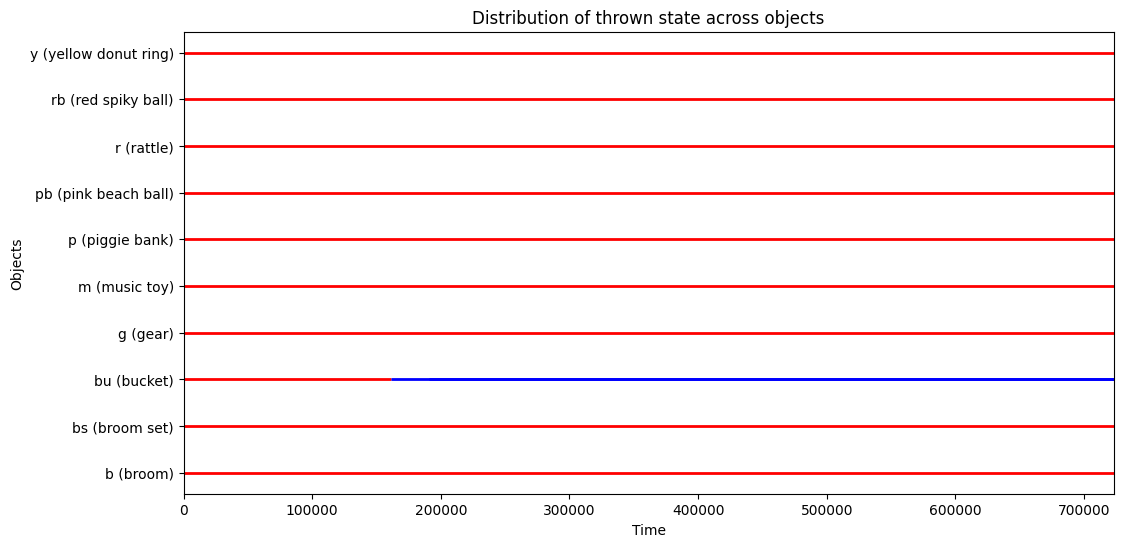

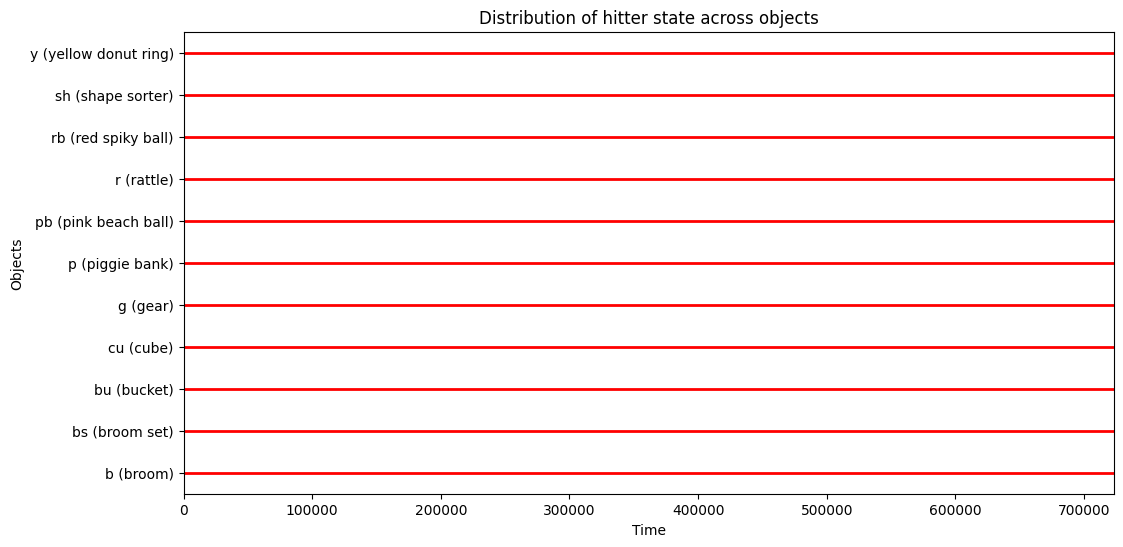

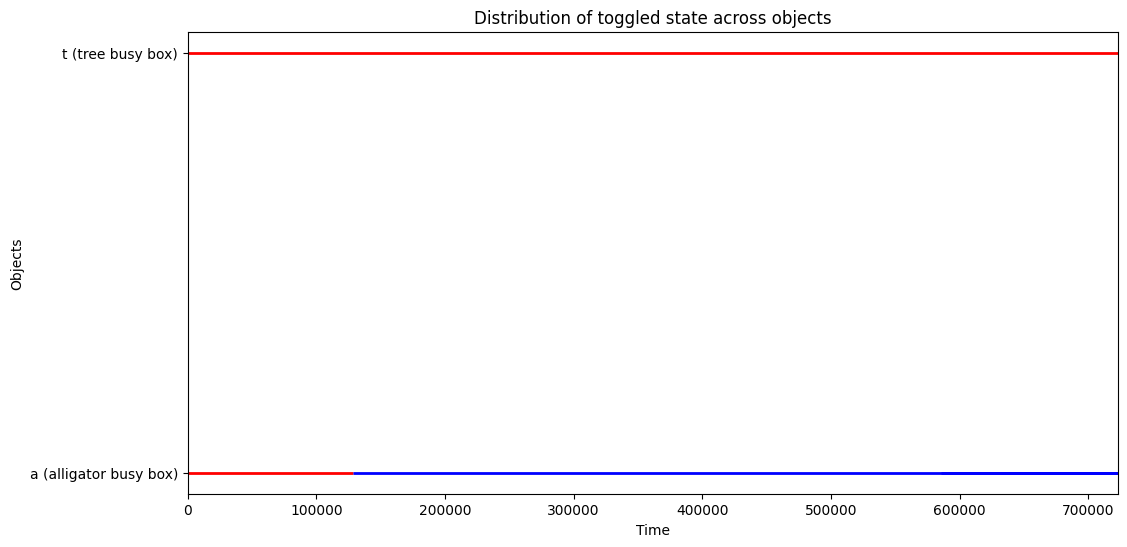

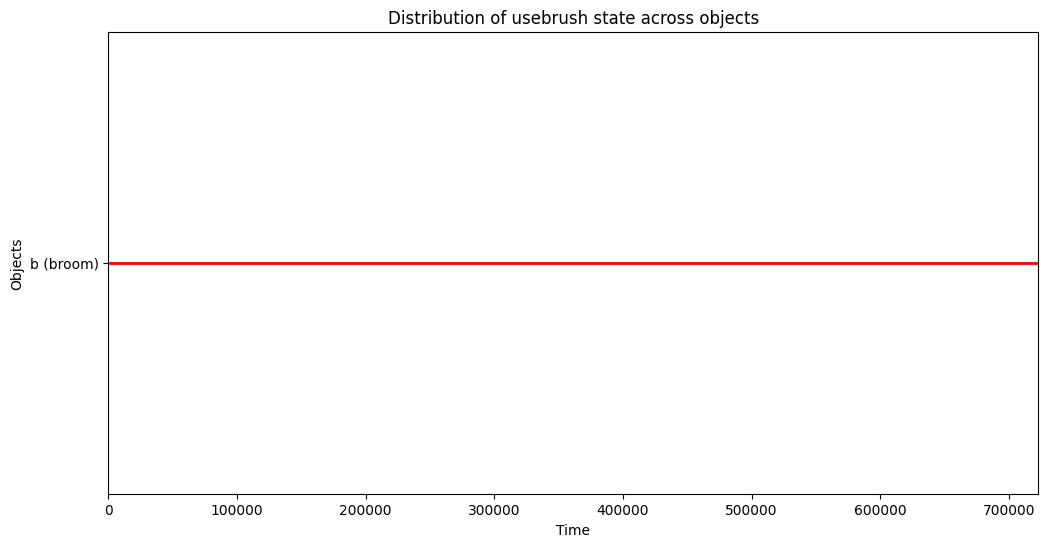

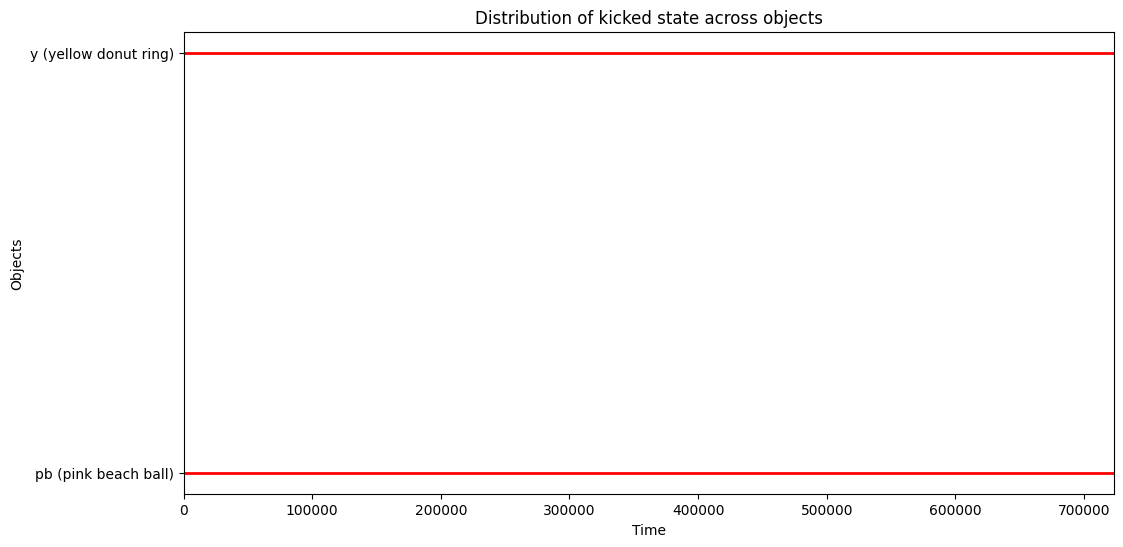

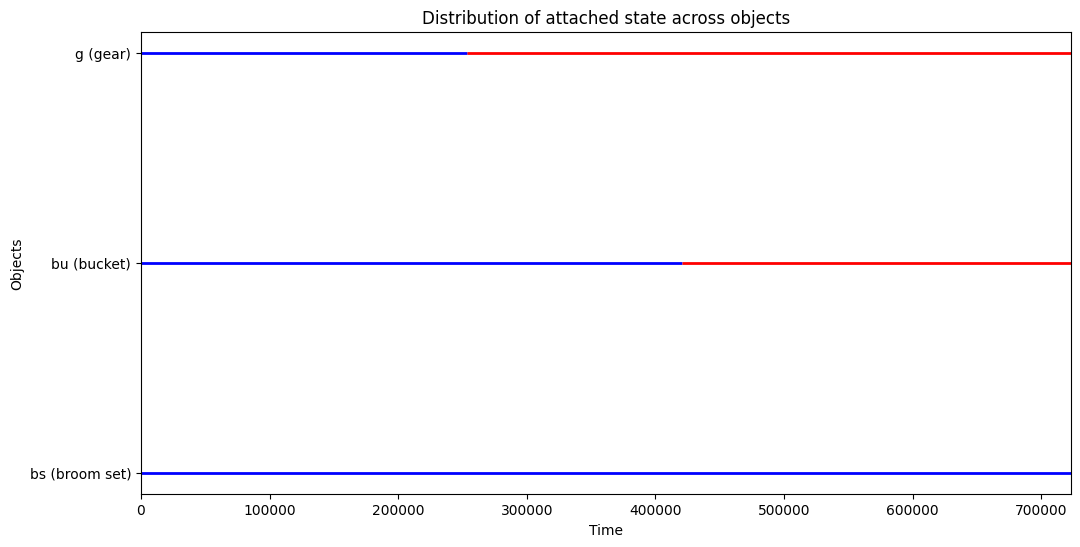

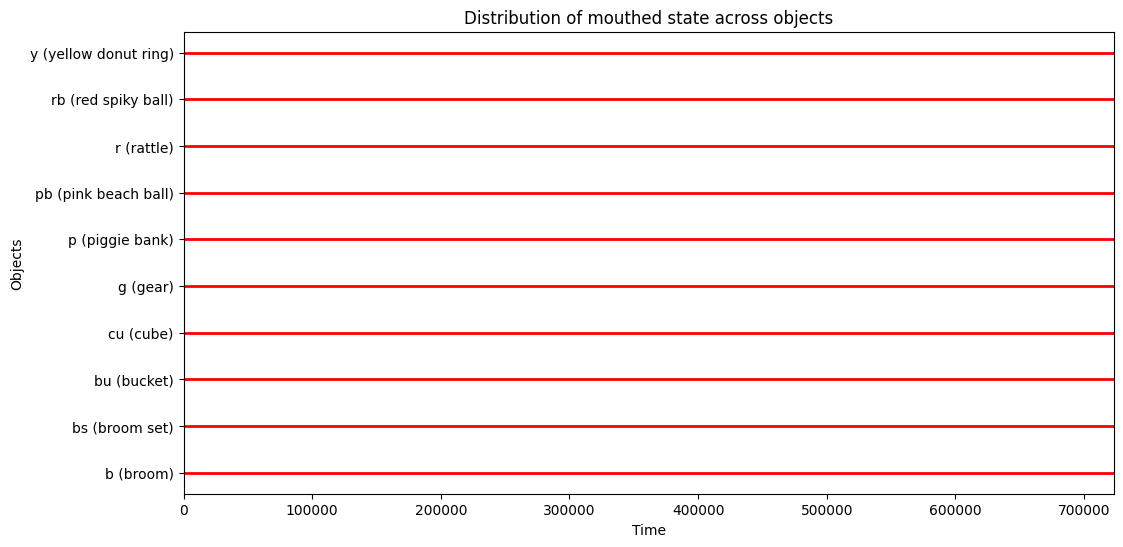

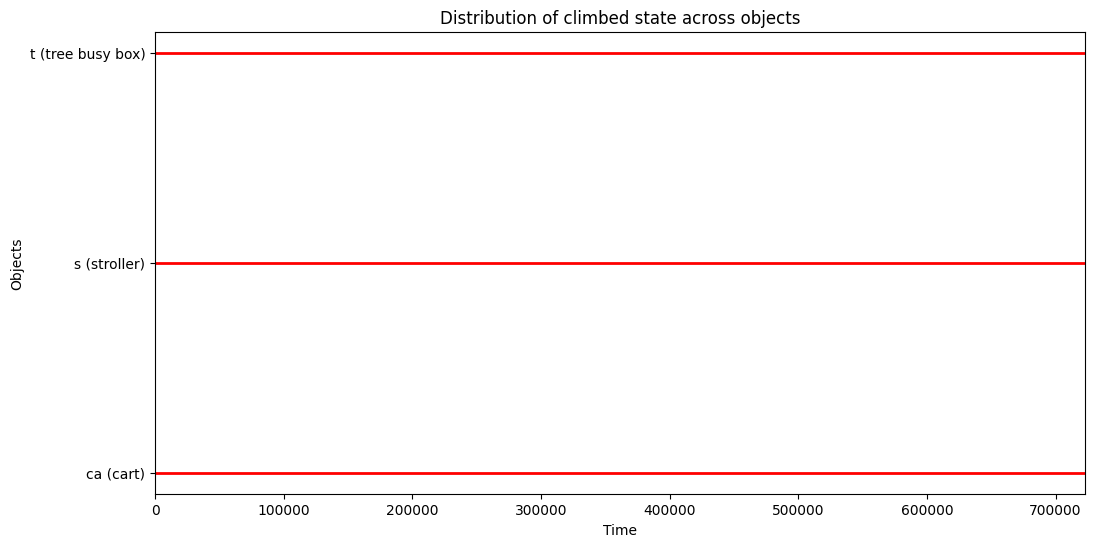

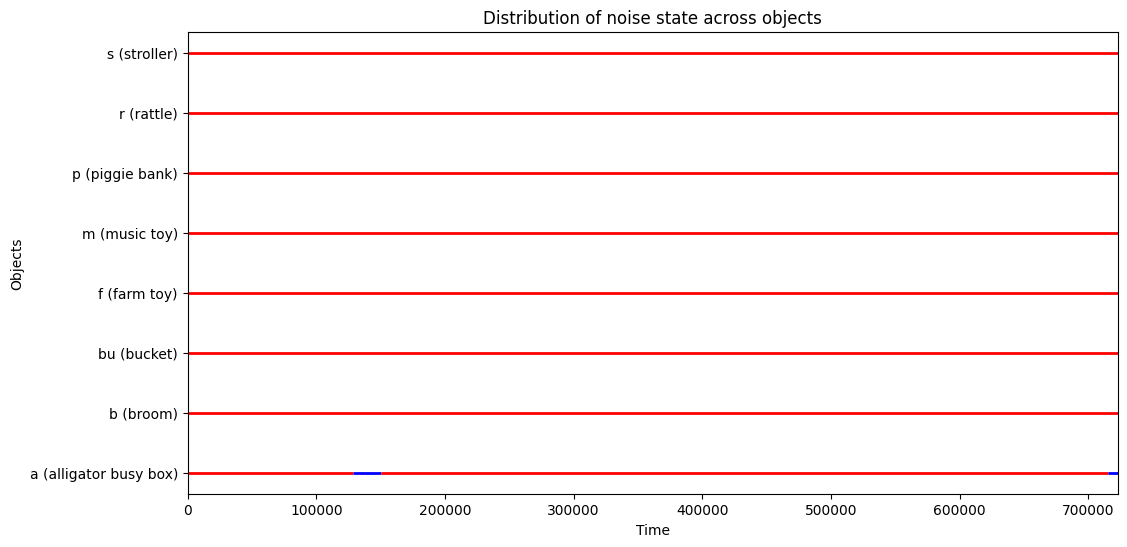

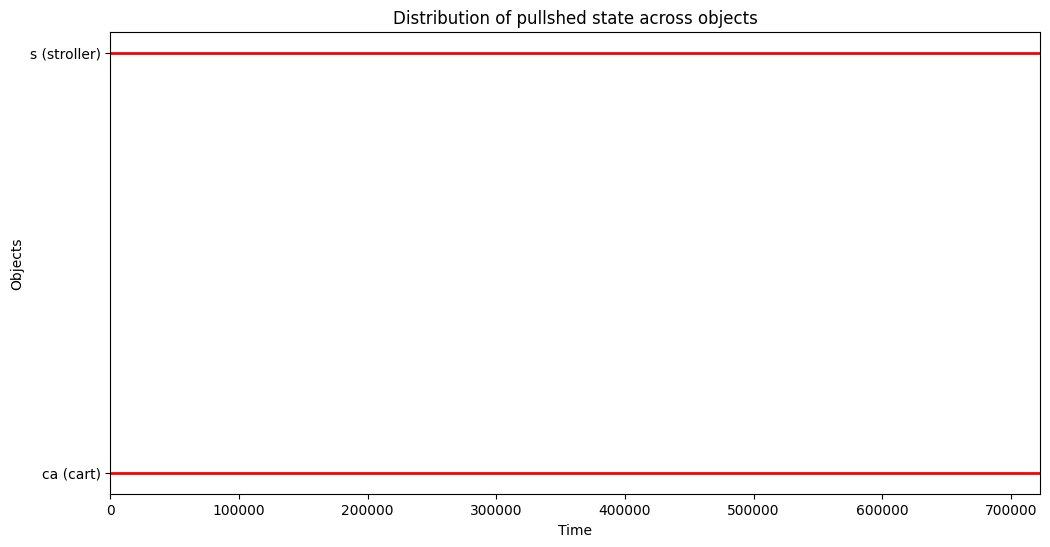

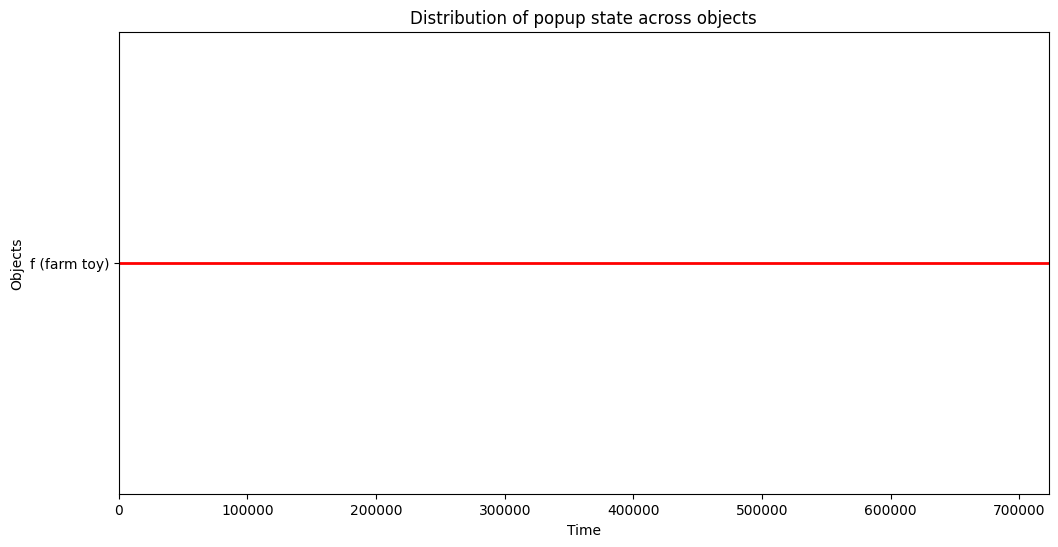

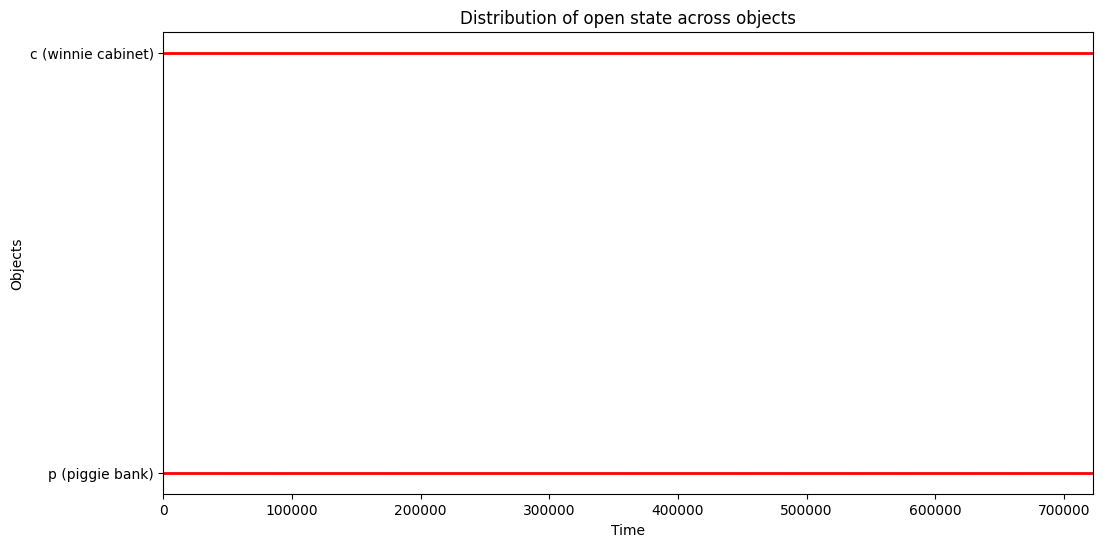

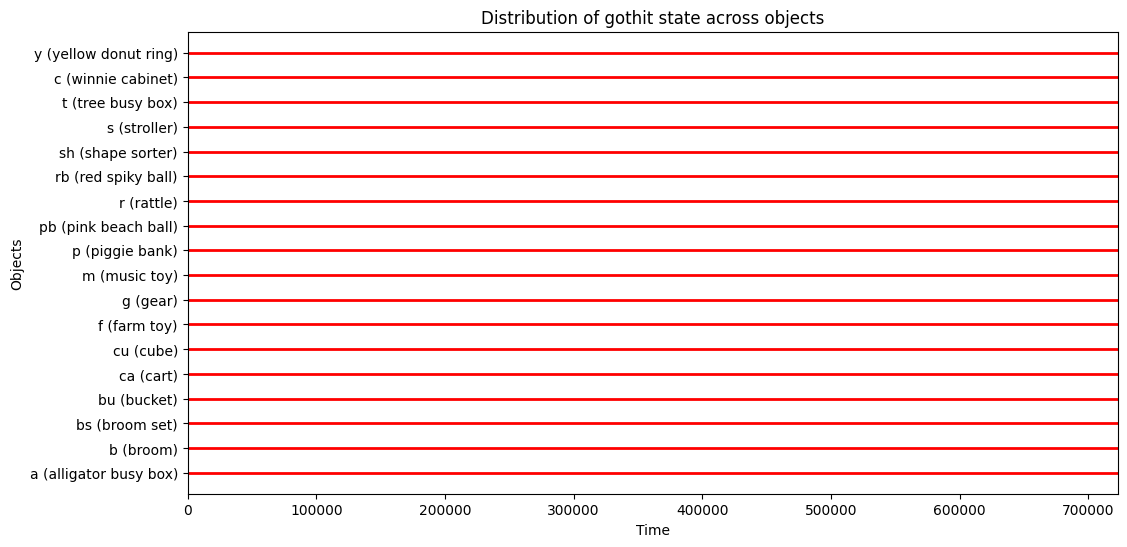

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique state types across all objects
state_types = set()
for obj_states in new_obj_states.values():
    state_types.update(obj_states.keys())

# Remove container-related states that don't have boolean values
state_types = {st for st in state_types if st not in ['contains', 'inside']}

# Find the maximum timepoint across all states and objects
max_time = 0
for obj_states in new_obj_states.values():
    for state_type, values in obj_states.items():
        if values:  # Check if there are any values
            for value in values:
                if isinstance(value[1], (int, float)):  # Check if time value is numeric
                    max_time = max(max_time, value[1])

# Create a plot for each state type
for state_type in state_types:
    plt.figure(figsize=(12, 6))
    plt.title(f'Distribution of {state_type} state across objects')
    plt.xlabel('Time')
    plt.ylabel('Objects')
    
    # Plot each object's values for this state
    y_ticks = []
    y_pos = 0
    for obj, states in new_obj_states.items():
        if state_type in states:
            y_ticks.append(f"{obj} ({obj_name_mapping.get(obj, obj)})")
            
            # Get state values and times
            values = states[state_type]
            current_state = False
            
            # Start with False state at time 0
            plt.hlines(y=y_pos, xmin=0, xmax=values[0][1], color='red', linewidth=2)
            
            for i in range(len(values)):
                if isinstance(values[i][0], bool):  # Only plot boolean states
                    start_time = values[i][1]
                    # If this is True state, draw until next False or end
                    if values[i][0]:
                        end_time = values[i+1][1] if i+1 < len(values) and not values[i+1][0] else max_time
                        plt.hlines(y=y_pos, xmin=start_time, xmax=end_time, color='blue', linewidth=2)
                    # For False states, draw gray line until next state
                    else:
                        next_time = values[i+1][1] if i+1 < len(values) else max_time
                        plt.hlines(y=y_pos, xmin=start_time, xmax=next_time, color='red', linewidth=2)
            
            y_pos += 1
    
    plt.yticks(range(len(y_ticks)), y_ticks)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xlim(0, max_time)  # Set x-axis limit to max time
    plt.show()
